# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 51     |  |
| :-------------|:-------------|
| Matteo Leonardi | 6391494 |
| Daniel Shou | 6501540 |
| Vera Reeringh | 6321046 |

## Opdracht 1: Planning.

| Planning Groep: 51     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 45 min | Vera |
| ontwerp-eis berekenen| 45 min | Daniel & Matteo|
| parameters bepalen | 30 min | hele groep |
| schets maken | 30 min | hele groep |
| lunchpauze | 12:45 - 13:45 | hele groep |
| opstelling gemaakt (eerste versie) | 15:00 | hele groep |
| Pauze 1| 15 min | hele groep |
| uiteindelijke opstelling gemaakt en meting af | 16:30 | hele groep |
| Pauze 2| 15 min | hele groep |
| opruimen en afsluiten | tot het einde | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | Er is goed met de setup te werken, de 1 meter draden geven voldoende ruimte om metingen te kunnen doen  |
| hoe lang voor één meting | Het duurt waarschijnlijk 5-20 seconden om een meting te doen|
| verwacht nauwkeurigheid meting | De verwachte nauwkeurigheid is 0.02 voor de Amplitude en 0.2 voor de frequentie |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

De eis wilt een amplitudevermindering van $\frac{1}{3}$ bij een frequentie van 5Hz. Eerst berekenen we de benodigde kantelfrequentie.\
formules uit het hoorcollege: 
$$
|\frac{A_m}{A_v} = |\frac{1}{ 1-\frac{\omega ^2}{\omega _0 ^2} }| \text{  met  } \omega _0 = 2\pi f_0
$$
Als we deze formule naar $ f_0 $ omvormen krijgen we:
$$
f_0 = \frac{f}{ \sqrt{(\frac{A_v}{A_m})+1} } = 2.5
$$


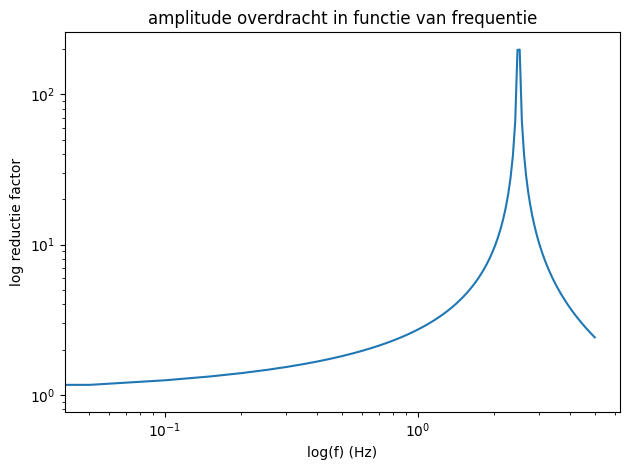

In [23]:
f_0 = 2.5

def demping_ratio(f):
    global f_0
    return 1/np.abs(1- np.sqrt(f/f_0))

frequenties = np.linspace(0,5,100)

plt.figure(dpi=100)
plt.title('amplitude overdracht in functie van frequentie')

plt.plot(frequenties, demping_ratio(frequenties))

plt.xscale('log')
plt.yscale('log')

plt.xlabel('log(f) (Hz)')
plt.ylabel('log reductie factor')

plt.tight_layout()
plt.show()

Deze kantelfrequentie gebruiken we om de minimale $ \Delta x$ te berekenen.\
uit het college hebben we:
$$
\omega _0 = 2\pi f_0 \text{  en  } \omega _0 = \sqrt{\frac{g}{\Delta x}}
$$
Dus dan krijgen we:
$$
\Delta x = \frac{ g }{ (2\pi f_0)^2 } = 0,04m
$$
om zeker te zijn nemen we voor ons ontwerp een $ \Delta x$ van 5cm.
In ons ontwerp is $\Delta x = \frac{m}{c} g$ waarbij m en c onze vrije parameters zijn.
In de volgende cel plotten we de $\Delta x$ tegen de ratio van m en c.

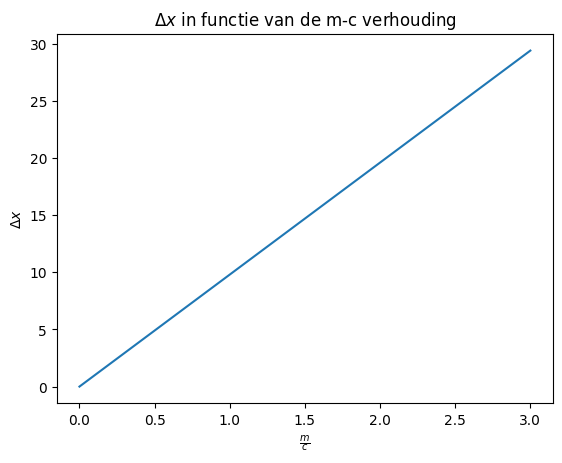

In [31]:
def delta_x(ratio):
    return (ratio)*9.81

ratios = np.linspace(0,3,100)

plt.figure(dpi=100)
plt.title(r'$\Delta x$ in functie van de m-c verhouding')

plt.plot(ratios, delta_x(ratios))

plt.xlabel(r'$\frac{m}{c}$')
plt.ylabel(r'$\Delta x$')

#plt.tight_layout()
plt.show()

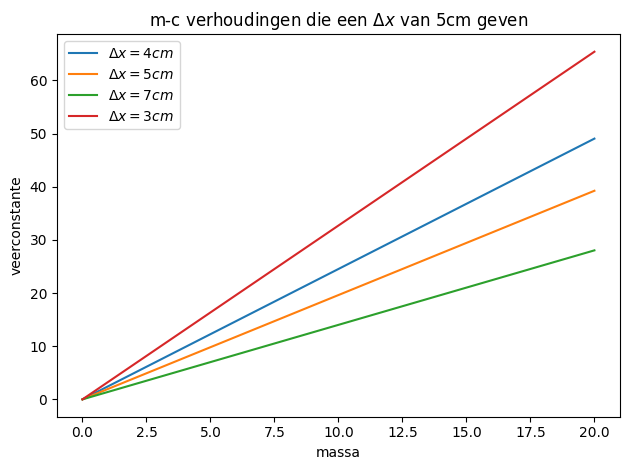

In [37]:

massa = np.linspace(0,20,100)

def veerconstante(massa, delta_x):
    return massa/(delta_x/9.81)

plt.figure(dpi=100)
plt.title(r'm-c verhoudingen die een $\Delta x$ van 5cm geven')

plt.plot(massa, veerconstante(massa,4), label=r'$\Delta x = 4cm$')
plt.plot(massa, veerconstante(massa,5), label=r'$\Delta x = 5cm$')
plt.plot(massa, veerconstante(massa,7), label=r'$\Delta x = 7cm$')
plt.plot(massa, veerconstante(massa,3), label=r'$\Delta x = 3cm$')

plt.xlabel('massa')
plt.ylabel('veerconstante')
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
# schattend rekenenen

import numpy as np

#schatting diameter draad

ondergrens = 0.0005 # 0.5 milimeter meter
bovengrens = 0.002 # 2 milimeter

schatting_diameter1 = np.sqrt(ondergrens * bovengrens)
print("diameter draad:", schatting_diameter1, "m")

pi = 3
r = schatting_diameter1 / 2

schatting_oppervlak = pi * r**2
print (round(schatting_oppervlak,9), "m^2")

#schatting oppervlak

ondergrens2 = 0.01 # 1 centimeter
bovengrens2 = 0.02 # 1.5 milimeter

schatting_diameter2 = np.sqrt(ondergrens2 * bovengrens2)
schatting_oppervlak2 = pi * (schatting_diameter2/2)**2 # dwarsoppervlak van de veer

#omtrek = pi * schatting_diameter2
#aant_omwentelingen = 18
#schatting_l0 = aant_omwentelingen * omtrek
#print("lengte draad: ", schatting_l0)

# eigenschappen veer

l0 = 0.079 # rustlengt veer in m
l = 0.085 # uitwijkingslengte veer
u = l-l0 # uitwijking

F = 0.4365 * 9.81 # gewicht in N dat aan de veer werd gehangen

C_veer = np.abs(F /u)
print ("Veerconstante:", C_veer, "N/m")

#schatting Young's modulus

E = (C_veer * l0) / schatting_oppervlak2 * 1e-9
print(E, "GPa")
print ("Onze schatting voor E is", round(E,7), "GPa")

diameter draad: 0.001 m
7.5e-07 m^2
Veerconstante: 713.6774999999994 N/m
0.0003758701499999997 GPa
Onze schatting voor E is 0.0003759 GPa


## Opdracht 3: Plot de grafiek.

In [16]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- kleinere veerconstante
- grotere massa

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 5cm

De formule stelt on in staat om de dempingsfactor te plotten voor de gekozen $\Delta x$. Als we de formule omvormen krijgen we:
$$
|\frac{A_m}{A_v}|_{(\Delta x)} = |\frac{1}{ 1 - \frac{2\pi f \Delta x}{g}} \text{   met f = 5Hz }
$$
Uit de grafiek blijkt dat grotere $\Delta x$ een grotere demping geven. Het is echter praktisch makkelijker om een kleine $\Delta x$ te gebruiken in de opstelling, wij kiezen daarom voor een $\Delta x$ van 5cm. Dit geeft ook wat extra veiligheidsmarge want de formule houd geen rekening met wrijving.

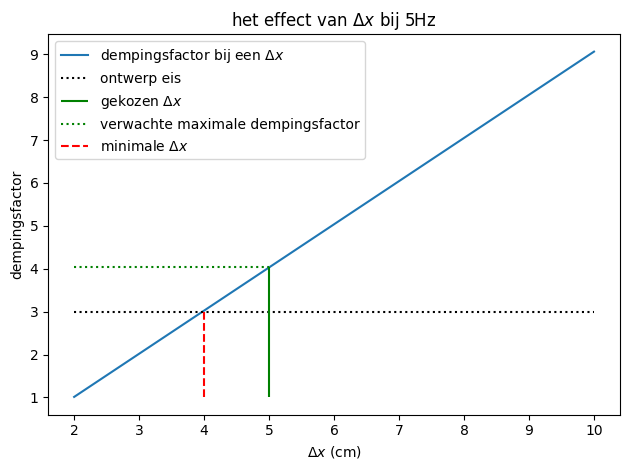

In [55]:
omega = 2*np.pi*5

def A_factor(delta_x):
    global omega
    return np.abs( 1 - ((omega**2)*delta_x/(100*9.81)))   # delen door 100: naar meter

delta_x_array = np.linspace(0.02, 0.1, 100)*100   # naar cm

plt.figure(dpi=100)
plt.title(r'het effect van $\Delta x$ bij 5Hz')

plt.plot(delta_x_array, A_factor(delta_x_array), label=r'dempingsfactor bij een $\Delta x$')
plt.hlines(y=3,xmin=2, xmax=10, linestyles=':', color='black', label='ontwerp eis')
plt.vlines(x=5, ymin=1, ymax=A_factor(5), linestyles='-', color='green', label=r'gekozen $\Delta x$')
plt.hlines(y=A_factor(5), xmin=2, xmax=5, linestyles=':', color='green', label='verwachte maximale dempingsfactor')
plt.vlines(x=4, ymin=1, ymax=3, linestyles='--', color='red', label=r'minimale $\Delta x$')

plt.xlabel(r'$\Delta x$ (cm)')
plt.ylabel('dempingsfactor')
plt.legend()

plt.tight_layout()
plt.show()

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="tudelftLogo.png" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

**4**

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

**6**

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

**Voeg hier je antwoord in**

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

**Ja, dat is genoeg omdat we de constructie zo hebben gemaakt dat het niet mogelijk is om verder dan dat gewicht te komen**

### Gaat je ontwerp dus voldoen aan de eis?

**Ja.**

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

In [ ]:
# Voeg hier je plot in.



## Opdracht 7: Plotten maar

In [18]:
# Voeg hier je plots in.

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

In [19]:
# Als je met Python je resultaten wil laten zien: voeg hier je code in.

#### Als je je figuren onderweg opgeslagen hebt, kan je ze hier invoegen:
<img src="tudelftLogo.png" width="400">
<img src="tudelftLogo.png" width="400">